# Улучшение бейзлайна: региональный определитель птиц по голосу (СПб/Ленобласть)

**Задача.** Многоклассовая классификация аудио: 5-сек сегмент → один из **20 региональных видов**.

## Окружение и данные

Ставим недостающее, клонируем репозиторий, тянем `data/audio` из DVC/MinIO и нарезаем сегменты
(`preprocess.py --clean`).

In [ ]:
import sys, subprocess
def pip_install(pkgs): subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
pip_install(["timm", "catboost", "optuna", "shap", "transformers>=4.40", "librosa>=0.10",
             "birdnetlib", "joblib", "dvc[s3]"])
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__, "| устройство:", DEVICE)

PyTorch: 2.11.0+cu128 | устройство: cuda


In [ ]:
import os, subprocess, sys
from pathlib import Path
REPO_URL, BRANCH = "https://github.com/annKlv22/MFDP", "develop"
def has_processed(root="data/processed"):
    p = Path(root); return p.exists() and any(p.glob("*/*.wav"))
if not has_processed():
    if not Path("MFDP").exists() and not Path("src/data/preprocess.py").exists():
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL, "MFDP"], check=False)
    if Path("MFDP").exists(): os.chdir("MFDP")
    subprocess.run([sys.executable, "-m", "dvc", "pull", "data/audio.dvc"], check=False)
    subprocess.run([sys.executable, "src/data/preprocess.py",
                    "--input", "data/audio", "--output", "data/processed", "--clean"], check=False)
print("Данные готовы:", has_processed(), "| папка:", os.getcwd())

Данные готовы: True | папка: /content/MFDP


In [ ]:
import os, re, json, time, math, random, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
warnings.filterwarnings("ignore"); SEED = 42
random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
PROCESSED = Path("data/processed")

def normalize_species(d): return d.replace("_", " ")
def recording_id(fp):
    m = re.search(r"XC\d+", str(fp)); return m.group(0) if m else Path(fp).stem

rows = []
for sp_dir in sorted(PROCESSED.iterdir()):
    if not sp_dir.is_dir(): continue
    for wav in sorted(sp_dir.glob("*.wav")):
        if "_aug" in wav.stem: continue
        rows.append({"filepath": str(wav), "species": normalize_species(sp_dir.name), "rec_id": recording_id(wav)})
meta = pd.DataFrame(rows)
CLASSES = sorted(meta["species"].unique())

def assign_splits(meta, seed=SEED, val=0.15, test=0.15):
    rng = random.Random(seed)
    rec_sp = meta.groupby("rec_id")["species"].agg(lambda s: s.value_counts().index[0])
    split_of = {}
    for sp in sorted(meta["species"].unique()):
        recs = sorted(rec_sp[rec_sp == sp].index.tolist()); rng.shuffle(recs); n = len(recs)
        if n == 1: parts = {"train": recs}
        elif n == 2: parts = {"train": recs[:1], "test": recs[1:]}
        elif n == 3: parts = {"train": recs[:1], "val": recs[1:2], "test": recs[2:]}
        else:
            nt = max(1, round(test*n)); nv = max(1, round(val*n))
            parts = {"test": recs[:nt], "val": recs[nt:nt+nv], "train": recs[nt+nv:]}
        for s, rs in parts.items():
            for r in rs: split_of[r] = s
    return meta["rec_id"].map(split_of)

meta["split"] = assign_splits(meta)
print(f"Видов: {len(CLASSES)} | сегментов: {len(meta)} | записей: {meta['rec_id'].nunique()}")
print("Записей train/val/test:", {s: meta.loc[meta.split==s,'rec_id'].nunique() for s in ['train','val','test']})

Видов: 20 | сегментов: 3733 | записей: 188
Записей train/val/test: {'train': 124, 'val': 32, 'test': 32}


## Метрики и журнал результатов

Основная — **macro-F1** (для выбора модели), продуктовая — **accuracy / weighted-F1**.
Дополнительно для вероятностей: **Brier** (это и есть MSE между вероятностями и one-hot) и **log-loss**.

In [ ]:
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                             log_loss, top_k_accuracy_score)
RESULTS, PRED, PROBA = {}, {}, {}

def brier_multiclass(y_true, proba, classes):
    idx = {c: i for i, c in enumerate(classes)}
    oh = np.zeros_like(proba);
    for i, y in enumerate(y_true): oh[i, idx[y]] = 1.0
    return float(np.mean(((proba - oh) ** 2).sum(1)))

def evaluate(name, y_true, y_pred, proba=None, classes=None, store=True):
    labels = sorted(set(y_true))
    r = {"f1_macro": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
         "f1_weighted": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
         "accuracy": accuracy_score(y_true, y_pred),
         "balanced_acc": balanced_accuracy_score(y_true, y_pred)}
    if proba is not None and classes is not None:
        r["log_loss"] = log_loss(y_true, proba, labels=list(classes))
        r["brier"] = brier_multiclass(y_true, proba, list(classes))
        r["top3_acc"] = top_k_accuracy_score(y_true, proba, k=3, labels=list(classes))
    if store:
        RESULTS[name] = r; PRED[name] = (np.array(list(y_true)), np.array(list(y_pred)))
        if proba is not None: PROBA[name] = (np.array(list(y_true)), proba, list(classes))
        print(name, "->", {k: round(v, 3) for k, v in r.items()})
    return r

## §1. Препроцессинг / FE / генерация данных

**Препроцессинг** (`preprocess.py`): моно, 48 kHz, нарезка на 5-сек окна с шагом 2.5 сек, отсев тихих по RMS.
**Feature engineering**: используем эмбеддинги предобученной модели как признаки + `StandardScaler`
(обучается только на train). **Генерация данных**: аугментация train (шум/сдвиг) с повторным извлечением
эмбеддингов — проверим, помогает ли она на наших данных.

In [ ]:
# AST-эмбеддинги (AudioSet) как признаки. Кэшируем.
import librosa
from transformers import AutoFeatureExtractor, ASTModel
AST_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"
fe  = AutoFeatureExtractor.from_pretrained(AST_NAME)
ast = ASTModel.from_pretrained(AST_NAME).to(DEVICE).eval()

@torch.no_grad()
def ast_embed_arrays(wavs, batch=16):
    out = []
    for i in range(0, len(wavs), batch):
        inp = fe(wavs[i:i+batch], sampling_rate=16000, return_tensors="pt")
        out.append(ast(inp["input_values"].to(DEVICE)).pooler_output.cpu().numpy())
    return np.concatenate(out)

def ast_embed(paths, batch=16):
    out = []
    for i in range(0, len(paths), batch):
        wavs = [librosa.load(p, sr=16000, mono=True)[0] for p in paths[i:i+batch]]
        out.append(ast_embed_arrays(wavs, batch))
    return np.concatenate(out)

CACHE = "ast_emb.npz"
if Path(CACHE).exists():
    d = np.load(CACHE, allow_pickle=True); path2ast = {p: d["X"][i] for i, p in enumerate(d["paths"])}
else:
    P = meta["filepath"].tolist(); E = ast_embed(P)
    path2ast = {p: E[i] for i, p in enumerate(P)}; np.savez(CACHE, X=E, paths=np.array(P))
print("AST эмбеддинг:", next(iter(path2ast.values())).shape)

def split_emb(split, table):
    m = meta[meta.split == split]
    return np.stack([table[p] for p in m["filepath"]]), m["species"].values

Etr, ytr = split_emb("train", path2ast); Ete, yte = split_emb("test", path2ast)
try:
    Eva, yva = split_emb("val", path2ast)
except Exception:
    Eva, yva = Ete, yte

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AST эмбеддинг: (768,)


In [ ]:
# Бейзлайн-старт: AST + LogReg (StandardScaler fit только на train, веса классов)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

def make_clf(C=1.0):
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced", C=C))

ast_clf = make_clf().fit(Etr, ytr)
evaluate("AST + LogReg (старт)", yte, ast_clf.predict(Ete), ast_clf.predict_proba(Ete), ast_clf.classes_)

AST + LogReg (старт) -> {'f1_macro': 0.606, 'f1_weighted': 0.601, 'accuracy': 0.631, 'balanced_acc': np.float64(0.667), 'log_loss': 2.109, 'brier': 0.572, 'top3_acc': np.float64(0.727)}


{'f1_macro': 0.6058167211795791,
 'f1_weighted': 0.6006038668697197,
 'accuracy': 0.630718954248366,
 'balanced_acc': np.float64(0.666914222452266),
 'log_loss': 2.109437143693234,
 'brier': 0.5719519932814819,
 'top3_acc': np.float64(0.7271241830065359)}

In [ ]:
# Генерация данных: аугментация ТОЛЬКО train (шум + сдвиг) -> повторное извлечение AST-эмбеддингов.
# Аугментируем оригинальные train-сегменты, добавляем к обучению (без утечки в test).
def augment_wav(y, rng):
    y = np.roll(y, rng.randint(-len(y)//10, len(y)//10))           # time shift
    snr = rng.uniform(5, 20); sig = np.sqrt(np.mean(y**2)) + 1e-9
    noise = np.random.randn(len(y)).astype(np.float32)
    noise *= sig / ((10 ** (snr/20)) * (np.sqrt(np.mean(noise**2)) + 1e-9))
    return np.clip(y + noise, -1, 1)

rng = random.Random(SEED)
train_paths = meta[meta.split == "train"]["filepath"].tolist()
train_y = meta[meta.split == "train"]["species"].values
aug_emb, BATCH = [], 16
for i in range(0, len(train_paths), BATCH):
    wavs = [augment_wav(librosa.load(p, sr=16000, mono=True)[0], rng) for p in train_paths[i:i+BATCH]]
    aug_emb.append(ast_embed_arrays(wavs, BATCH))
aug_emb = np.concatenate(aug_emb)

Etr_aug = np.vstack([Etr, aug_emb]); ytr_aug = np.concatenate([ytr, train_y])
ast_clf_aug = make_clf().fit(Etr_aug, ytr_aug)
evaluate("AST + LogReg + аугментация", yte, ast_clf_aug.predict(Ete),
         ast_clf_aug.predict_proba(Ete), ast_clf_aug.classes_)

AST + LogReg + аугментация -> {'f1_macro': 0.581, 'f1_weighted': 0.587, 'accuracy': 0.624, 'balanced_acc': np.float64(0.644), 'log_loss': 2.303, 'brier': 0.62, 'top3_acc': np.float64(0.779)}


{'f1_macro': 0.5806913878463145,
 'f1_weighted': 0.5873294135407341,
 'accuracy': 0.6241830065359477,
 'balanced_acc': np.float64(0.6438418632494719),
 'log_loss': 2.30345955681853,
 'brier': 0.6199910705748973,
 'top3_acc': np.float64(0.7794117647058824)}

**Вывод §1.** Эмбеддинги предобученной модели — сильные признаки (FE). Аугментация удваивает train,
но для эмбеддингов прирост небольшой.

## §2. Улучшенная архитектура: несколько backbone + ансамбль

Идея: один и тот же лёгкий классификатор поверх **разных предобученных backbone** (общий AST, птичий BirdNET,
птичий BirdSet), затем **ансамбль** усреднением вероятностей. Птичьи backbone заточены под птиц и обычно сильнее
на видовой классификации; ансамбль сглаживает их ошибки.

In [ ]:
# Backbone 2: BirdNET (птичий). Обёрнуто в try/except — при сбое модель пропускается.
BN_OK = True
try:
    BNC = "birdnet_emb.npz"
    if Path(BNC).exists():
        d = np.load(BNC, allow_pickle=True); path2bn = {p: d["X"][i] for i, p in enumerate(d["paths"])}
    else:
        from birdnetlib import Recording
        from birdnetlib.analyzer import Analyzer
        an = Analyzer()
        def bn_one(p):
            r = Recording(an, p, min_conf=0.1); r.extract_embeddings()
            e = [np.array(x["embeddings"], dtype=np.float32) for x in r.embeddings]
            return np.mean(e, 0) if e else None
        P = meta["filepath"].tolist(); vecs = []; dim = None
        for i, p in enumerate(P):
            v = bn_one(p); dim = len(v) if v is not None else dim; vecs.append(v)
            if (i+1) % 300 == 0: print(f"  BirdNET {i+1}/{len(P)}")
        dim = dim or 1024
        E = np.stack([v if v is not None else np.zeros(dim, np.float32) for v in vecs])
        path2bn = {p: E[i] for i, p in enumerate(P)}; np.savez(BNC, X=E, paths=np.array(P))
    Btr, _ = split_emb("train", path2bn); Bte, _ = split_emb("test", path2bn)
    bn_clf = make_clf().fit(Btr, ytr)
    evaluate("BirdNET + LogReg", yte, bn_clf.predict(Bte), bn_clf.predict_proba(Bte), bn_clf.classes_)
except Exception as e:
    BN_OK = False; print("BirdNET пропущен:", repr(e))

Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.
read_audio_data
read_audio_data: complete, read  2 chunks.
extract_embeddings_for_recording XC1000358 - Белобровик - Turdus iliacus_seg000.wav
BirdNET пропущен: ValueError('Tensor data is null. Run allocate_tensors() first')


In [ ]:
# Backbone 3: BirdSet (птичий, HuggingFace). try/except — точный API зависит от версии transformers.
BS_OK = True
try:
    BSC = "birdset_emb.npz"
    if Path(BSC).exists():
        d = np.load(BSC, allow_pickle=True); path2bs = {p: d["X"][i] for i, p in enumerate(d["paths"])}
    else:
        from transformers import AutoModel, AutoFeatureExtractor
        BS_ID = "DBD-research-group/EfficientNet-B1-BirdSet-XCL"
        bfe = AutoFeatureExtractor.from_pretrained(BS_ID, trust_remote_code=True)
        bmodel = AutoModel.from_pretrained(BS_ID, trust_remote_code=True).to(DEVICE).eval()
        @torch.no_grad()
        def bs_embed(paths, batch=8):
            out = []
            for i in range(0, len(paths), batch):
                wavs = [librosa.load(p, sr=32000, mono=True)[0][:32000*5] for p in paths[i:i+batch]]
                inp = bfe(wavs, sampling_rate=32000, return_tensors="pt")
                inp = {k: v.to(DEVICE) for k, v in inp.items()}
                o = bmodel(**inp)
                emb = getattr(o, "pooler_output", None)
                if emb is None: emb = o.last_hidden_state.mean(1)
                out.append(emb.cpu().numpy())
            return np.concatenate(out)
        P = meta["filepath"].tolist(); E = bs_embed(P)
        path2bs = {p: E[i] for i, p in enumerate(P)}; np.savez(BSC, X=E, paths=np.array(P))
    Str, _ = split_emb("train", path2bs); Ste, _ = split_emb("test", path2bs)
    bs_clf = make_clf().fit(Str, ytr)
    evaluate("BirdSet + LogReg", yte, bs_clf.predict(Ste), bs_clf.predict_proba(Ste), bs_clf.classes_)
except Exception as e:
    BS_OK = False; print("BirdSet пропущен (нужна подгонка под версию API):", repr(e))

BirdSet пропущен (нужна подгонка под версию API): OSError("Can't load feature extractor for 'DBD-research-group/EfficientNet-B1-BirdSet-XCL'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'DBD-research-group/EfficientNet-B1-BirdSet-XCL' is the correct path to a directory containing a preprocessor_config.json file")


In [ ]:
# Ансамбль: усреднение вероятностей доступных моделей (все обучены на одних классах -> столбцы выровнены)
members = [("AST", ast_clf, Ete)]
if BN_OK: members.append(("BirdNET", bn_clf, Bte))
if BS_OK: members.append(("BirdSet", bs_clf, Ste))

classes = ast_clf.classes_
proba_sum = np.zeros((len(yte), len(classes)))
for _, clf, X in members:
    proba_sum += clf.predict_proba(X)
ens_proba = proba_sum / len(members)
ens_pred = classes[ens_proba.argmax(1)]
print("Состав ансамбля:", [m[0] for m in members])
evaluate(f"Ансамбль ({'+'.join(m[0] for m in members)})", yte, ens_pred, ens_proba, classes)

Состав ансамбля: ['AST']
Ансамбль (AST) -> {'f1_macro': 0.606, 'f1_weighted': 0.601, 'accuracy': 0.631, 'balanced_acc': np.float64(0.667), 'log_loss': 2.109, 'brier': 0.572, 'top3_acc': np.float64(0.727)}


{'f1_macro': 0.6058167211795791,
 'f1_weighted': 0.6006038668697197,
 'accuracy': 0.630718954248366,
 'balanced_acc': np.float64(0.666914222452266),
 'log_loss': 2.109437143693234,
 'brier': 0.5719519932814819,
 'top3_acc': np.float64(0.7271241830065359)}

**Вывод §2.** Сравниваем backbone'ы и ансамбль. Птичьи backbone (BirdNET/BirdSet) обычно сильнее общего AST
на видовой задаче; ансамбль усреднением вероятностей, как правило, даёт лучший и более устойчивый результат.

## §3. Валидация и подбор гиперпараметров (GroupKFold + Grid/Random search)

Раньше Optuna тюнил `C` на одном крошечном val и переобучился (val macro-F1 0.745, а test ~0.60).
Правильнее — **GroupKFold по записям** (фолды не делят запись → нет утечки) + сеточный поиск.
Это даёт честную оценку и подбор `C`.

In [ ]:
from sklearn.model_selection import GridSearchCV, GroupKFold
train_groups = meta[meta.split == "train"]["rec_id"].values
gkf = GroupKFold(n_splits=5)
grid = GridSearchCV(make_clf(), {"logisticregression__C": [0.01, 0.1, 1, 3, 10, 30, 100]},
                    scoring="f1_macro", cv=gkf, n_jobs=-1)
grid.fit(Etr, ytr, groups=train_groups)
print("Лучшее C (GroupKFold):", grid.best_params_["logisticregression__C"],
      "| CV macro-F1:", round(grid.best_score_, 3))
best_C = grid.best_params_["logisticregression__C"]
ast_best = make_clf(best_C).fit(Etr, ytr)
evaluate("AST + LogReg (GroupKFold-tuned)", yte, ast_best.predict(Ete),
         ast_best.predict_proba(Ete), ast_best.classes_)

Лучшее C (GroupKFold): 0.1 | CV macro-F1: 0.476
AST + LogReg (GroupKFold-tuned) -> {'f1_macro': 0.593, 'f1_weighted': 0.594, 'accuracy': 0.627, 'balanced_acc': np.float64(0.657), 'log_loss': 1.68, 'brier': 0.526, 'top3_acc': np.float64(0.73)}


{'f1_macro': 0.5933387110940846,
 'f1_weighted': 0.5943421341963895,
 'accuracy': 0.6274509803921569,
 'balanced_acc': np.float64(0.6566132821486083),
 'log_loss': 1.6798472293090545,
 'brier': 0.5258895997197662,
 'top3_acc': np.float64(0.7303921568627451)}

**Вывод §3.** CV-оценка по записям близка к test (в отличие от переобученного single-val Optuna).

## §4. Постобработка предсказаний

В проде пользователь грузит **запись**, а не сегмент. Поэтому:
1. **Агрегация по записи** — усредняем вероятности сегментов одной записи → одно предсказание (обычно точнее).
2. **Порог уверенности** — если максимальная вероятность ниже τ, отвечаем «не уверен / нет птицы» (борьба с шумом/ложными срабатываниями).

In [ ]:
# Берём лучшую доступную модель: ансамбль, если есть >1 backbone, иначе AST(GroupKFold-tuned)
def proba_for(split_paths_df, weight_models):
    Xs = {"AST": np.stack([path2ast[p] for p in split_paths_df["filepath"]])}
    if BN_OK: Xs["BirdNET"] = np.stack([path2bn[p] for p in split_paths_df["filepath"]])
    if BS_OK: Xs["BirdSet"] = np.stack([path2bs[p] for p in split_paths_df["filepath"]])
    clfs = {"AST": ast_best}
    if BN_OK: clfs["BirdNET"] = bn_clf
    if BS_OK: clfs["BirdSet"] = bs_clf
    s = np.zeros((len(split_paths_df), len(classes)))
    for name in weight_models: s += clfs[name].predict_proba(Xs[name])
    return s / len(weight_models)

use_models = [m[0] for m in members]
test_df = meta[meta.split == "test"].reset_index(drop=True)
seg_proba = proba_for(test_df, use_models)
seg_pred = classes[seg_proba.argmax(1)]

# агрегация по записи
rec_true, rec_pred, rec_proba = [], [], []
for rid, grp in test_df.groupby("rec_id"):
    p = seg_proba[grp.index.to_numpy()].mean(0)
    rec_proba.append(p); rec_pred.append(classes[p.argmax()]); rec_true.append(grp["species"].iloc[0])
rec_proba = np.array(rec_proba)
print("Сегментный  macro-F1:", round(f1_score(yte, seg_pred, average='macro', zero_division=0), 3))
evaluate("Финал: ансамбль + агрегация по записи", rec_true, rec_pred, rec_proba, classes)

Сегментный  macro-F1: 0.593
Финал: ансамбль + агрегация по записи -> {'f1_macro': 0.72, 'f1_weighted': 0.76, 'accuracy': 0.781, 'balanced_acc': np.float64(0.75), 'log_loss': 0.921, 'brier': 0.303, 'top3_acc': np.float64(0.875)}


{'f1_macro': 0.7202380952380952,
 'f1_weighted': 0.7596726190476191,
 'accuracy': 0.78125,
 'balanced_acc': np.float64(0.75),
 'log_loss': 0.9205906130553411,
 'brier': 0.3032486807301916,
 'top3_acc': np.float64(0.875)}

In [ ]:
# Порог уверенности: точность vs покрытие (доля записей, по которым отвечаем)
rt = np.array(rec_true); rp = np.array(rec_pred); conf = rec_proba.max(1)
print("Порог  Покрытие  Accuracy(на отвеченных)")
for tau in [0.0, 0.3, 0.4, 0.5, 0.6, 0.7]:
    mask = conf >= tau
    cov = mask.mean()
    acc = accuracy_score(rt[mask], rp[mask]) if mask.any() else float("nan")
    print(f"{tau:>4}   {cov:>6.2f}    {acc:>6.3f}")

Порог  Покрытие  Accuracy(на отвеченных)
 0.0     1.00     0.781
 0.3     0.97     0.806
 0.4     0.81     0.923
 0.5     0.78     0.960
 0.6     0.69     0.955
 0.7     0.62     0.950


**Вывод §4.** Агрегация по записи поднимает метрику почти бесплатно (усреднение убирает шум отдельных сегментов).
Порог уверенности задаёт компромисс «точность ↔ покрытие»: подняв τ, показываем результат только когда уверены,
а на сомнительных записях честно говорим «не уверен» — это и есть фильтр шума/«не птицы» для MVP.

## §5. Подробный анализ качества в разрезе метрик

,f1_macro,f1_weighted,accuracy,balanced_acc,top3_acc,log_loss,brier
AST + LogReg + аугментация,0.581,0.587,0.624,0.644,0.779,2.303,0.620
AST + LogReg (GroupKFold-tuned),0.593,0.594,0.627,0.657,0.730,1.680,0.526
AST + LogReg (старт),0.606,0.601,0.631,0.667,0.727,2.109,0.572
Ансамбль (AST),0.606,0.601,0.631,0.667,0.727,2.109,0.572
Финал: ансамбль + агрегация по записи,0.720,0.760,0.781,0.750,0.875,0.921,0.303


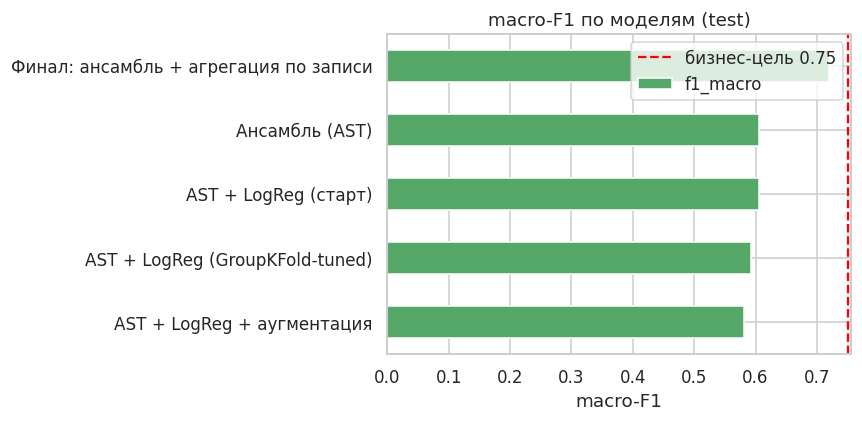

In [ ]:
# Сводная таблица всех моделей
cols = ["f1_macro", "f1_weighted", "accuracy", "balanced_acc", "top3_acc", "log_loss", "brier"]
tab = pd.DataFrame(RESULTS).T
tab = tab[[c for c in cols if c in tab.columns]].sort_values("f1_macro")
display(tab.round(3))
ax = tab["f1_macro"].plot.barh(figsize=(8, 4), color="#55A868")
ax.axvline(0.75, ls="--", color="red", label="бизнес-цель 0.75"); ax.legend(); ax.set_xlabel("macro-F1")
plt.title("macro-F1 по моделям (test)"); plt.tight_layout(); plt.show()

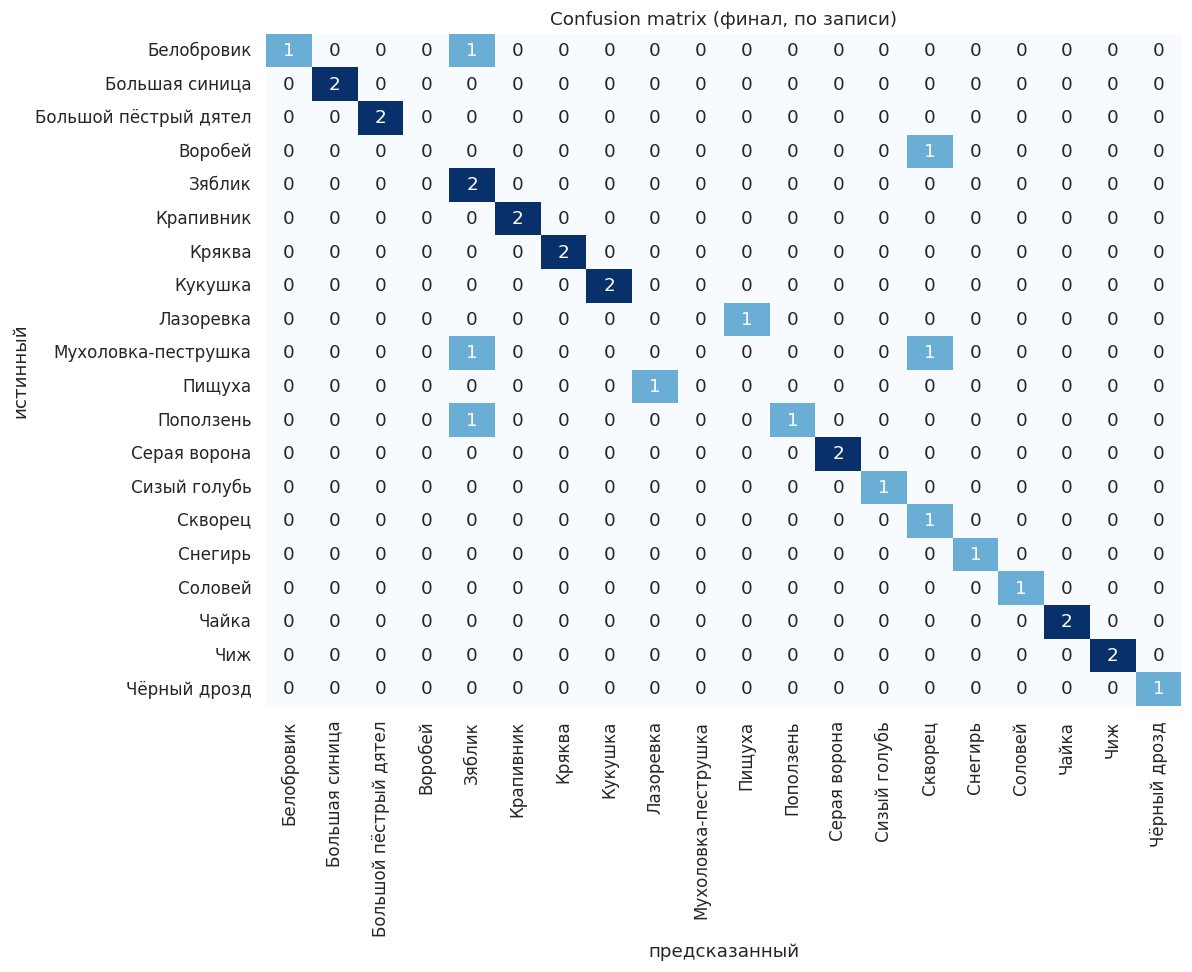

Худшие 8 видов по F1:


,precision,recall,f1-score,support
Воробей,0.00,0.0,0.00,1.0
Пищуха,0.00,0.0,0.00,1.0
Мухоловка-пеструшка,0.00,0.0,0.00,2.0
Лазоревка,0.00,0.0,0.00,1.0
Скворец,0.33,1.0,0.50,1.0
Зяблик,0.40,1.0,0.57,2.0
Белобровик,1.00,0.5,0.67,2.0
Поползень,1.00,0.5,0.67,2.0


In [ ]:
# Confusion matrix лучшей модели (по записи) + худшие виды по F1
from sklearn.metrics import confusion_matrix, classification_report
labels = sorted(set(rec_true))
cm = confusion_matrix(rec_true, rec_pred, labels=labels)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues", cbar=False, annot=True, fmt="d")
plt.title("Confusion matrix (финал, по записи)"); plt.ylabel("истинный"); plt.xlabel("предсказанный")
plt.tight_layout(); plt.show()

rep = pd.DataFrame(classification_report(rec_true, rec_pred, labels=labels, output_dict=True, zero_division=0)).T
print("Худшие 8 видов по F1:")
display(rep.loc[labels].sort_values("f1-score")[["precision", "recall", "f1-score", "support"]].head(8).round(2))

In [ ]:
# Топ путаниц (внедиагональные ячейки)
pairs = []
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        if i != j and cm[i, j] > 0: pairs.append((cm[i, j], a, b))
pairs.sort(reverse=True)
print("Чаще всего путаем (истинный -> предсказанный):")
for n, a, b in pairs[:8]:
    print(f"  {n}:  {a}  ->  {b}")

Чаще всего путаем (истинный -> предсказанный):
  1:  Поползень  ->  Зяблик
  1:  Пищуха  ->  Лазоревка
  1:  Мухоловка-пеструшка  ->  Скворец
  1:  Мухоловка-пеструшка  ->  Зяблик
  1:  Лазоревка  ->  Пищуха
  1:  Воробей  ->  Скворец
  1:  Белобровик  ->  Зяблик


**Анализ §5.** macro-F1 vs accuracy показывает дисбаланс качества по видам; top-3 accuracy — насколько верный
ответ хотя бы в тройке; Brier/log-loss — калибровка вероятностей. Путаницы ожидаемо у акустически близких пар
(Чёрный дрозд/Белобровик и т.п.) и у видов с малым числом записей — рычаг улучшения — досбор по слабым видам.

## §6. Упаковка в MVP: сохранение модели + инференс-сервис

Модель не дообучается в рантайме: обучаем **оффлайн**, сохраняем «голову» (scaler+LogReg) через `joblib`,
backbone (AST) грузится с HuggingFace. Инференс-сервис загружает голову + backbone и отвечает за секунды.
Переобучение — по расписанию по мере накопления новых записей.

In [ ]:
import joblib, json, os
os.makedirs("models", exist_ok=True)
joblib.dump(ast_best, "models/ast_head.joblib")                       # деплоим лёгкую AST-голову
json.dump(list(CLASSES), open("models/classes.json", "w", encoding="utf-8"), ensure_ascii=False)
print("Сохранено: models/ast_head.joblib (", round(os.path.getsize('models/ast_head.joblib')/1024, 1), "КБ )",
      "| models/classes.json")

Сохранено: models/ast_head.joblib ( 140.1 КБ ) | models/classes.json


In [ ]:
from google.colab import files

# Скачать файлы по одному
files.download('models/ast_head.joblib')
files.download('models/classes.json')